# Simultaneous destabilization demo
This notebook reproduces `scripts/simultaneous_destabilization_demo.py` and inspects artifacts in `results/simultaneous_destabilization/`.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpmgame import AttackCandidate, MaskDefense, SimultaneousProblem, analyze_simultaneous_attacks, write_analysis_outputs

C:\Users\perry\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def build_toy_problem(seed: int = 17) -> SimultaneousProblem:
    rng = np.random.default_rng(seed)
    masks = [
        MaskDefense('∇1', np.array([1, 1, 0, 1, 0, 0], dtype=int), threshold=1.9),
        MaskDefense('∇2', np.array([1, 0, 1, 0, 1, 0], dtype=int), threshold=1.7),
        MaskDefense('∇3', np.array([0, 1, 1, 0, 0, 1], dtype=int), threshold=1.6),
        MaskDefense('∇4', np.array([1, 0, 0, 1, 0, 1], dtype=int), threshold=1.5),
    ]
    base = rng.uniform(0.2, 1.2, size=(4, 6))
    attacks = [AttackCandidate(f'Δ{i+1}', base[i]) for i in range(base.shape[0])]
    sensitivity = np.array([1.0, 1.2, 0.8, 1.1, 1.05, 0.95], dtype=float)
    return SimultaneousProblem(masks=masks, attacks=attacks, sensitivity=sensitivity)

problem = build_toy_problem()
analysis = analyze_simultaneous_attacks(problem, include_additive=True, additive_max_terms=2)
out = Path('results/simultaneous_destabilization')
write_analysis_outputs(analysis, out)

{'cross_success_csv': WindowsPath('results/simultaneous_destabilization/cross_success_matrix.csv'),
 'support_overlap_csv': WindowsPath('results/simultaneous_destabilization/support_overlap_matrix.csv'),
 'dominance_json': WindowsPath('results/simultaneous_destabilization/dominance_relations.json'),
 'coverage_json': WindowsPath('results/simultaneous_destabilization/coverage_by_attack.json'),
 'additive_json': WindowsPath('results/simultaneous_destabilization/additive_attacks.json')}

In [3]:
analysis.cross_success

,∇1,∇2,∇3,∇4
Δ1,1,1,0,1
Δ2,0,1,1,1
Δ3,1,1,1,0
Δ4,0,0,0,1
Δ1 + Δ2,1,1,1,1
Δ1 + Δ3,1,1,1,1
Δ1 + Δ4,1,1,1,1
Δ2 + Δ3,1,1,1,1
Δ2 + Δ4,1,1,1,1
Δ3 + Δ4,1,1,1,1


In [4]:
analysis.support_overlap

,∇1,∇2,∇3,∇4
∇1,1.0,0.2,0.2,0.5
∇2,0.2,1.0,0.2,0.2
∇3,0.2,0.2,1.0,0.2
∇4,0.5,0.2,0.2,1.0


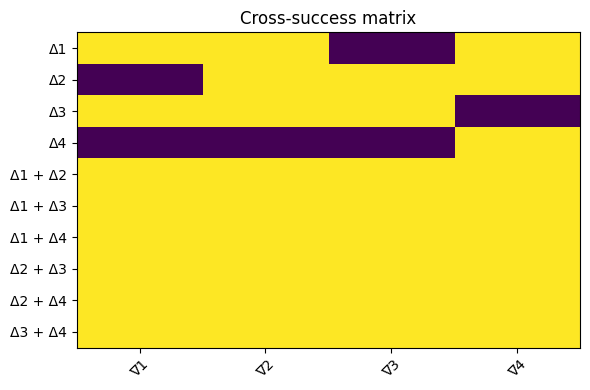

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
ax.imshow(analysis.cross_success.to_numpy(dtype=float), aspect='auto', cmap='viridis')
ax.set_title('Cross-success matrix')
ax.set_xticks(range(len(analysis.cross_success.columns)), analysis.cross_success.columns, rotation=45)
ax.set_yticks(range(len(analysis.cross_success.index)), analysis.cross_success.index)
plt.tight_layout()

## Artifact references
Generated outputs are stored in:
- `results/simultaneous_destabilization/cross_success_matrix.csv`
- `results/simultaneous_destabilization/support_overlap_matrix.csv`
- `results/simultaneous_destabilization/dominance_relations.json`
- `results/simultaneous_destabilization/coverage_by_attack.json`
- `results/simultaneous_destabilization/additive_attacks.json`
- script-generated figures (`*_heatmap.png`, `coverage_frequency.png`)